In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
import numpy as np
from scipy import optimize
import importlib
import functions_to_import as fhealthy
import solver.model
importlib.reload(solver.model)
importlib.reload(solver.model.cwrapping)
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


In [2]:
def default_plot(f,m,index,n_cycles,Tc,tFinal,color,draw):
    
    idx = m.t > tFinal - n_cycles*Tc
    plt.sca(f[0])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('LV','Pi')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('AA_RCL','Pi')[idx],color=color,linestyle='--',linewidth = 1.5)
    if draw:
        time = (m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0])
        diff = np.diff(m.getVariable('RA','Qo')[idx])
        p1 = time[np.where(diff>0)[-1][-1]]
        closed = time[np.where(m.getVariable('RA','Qo')[idx]<0.1)[-1]]
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Pressure (mmHg)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,60])
    f[0].set_title('Left ventricle and aorta')

    plt.sca(f[1])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('LV','Qo')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('LA','Qo')[idx],color=color,linestyle='--',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Blood flow (ml/s)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,50])
    f[1].set_title('Aortic and mitral valves')

    plt.sca(f[2])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('RV','Pi')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('PA_RCL','Pi')[idx],color=color,linestyle='--',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Pressure (mmHg)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,60])
    f[2].set_title('Right ventricle and pulmonary artery')

    plt.sca(f[3])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('RV','Qo')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('RA','Qo')[idx],color=color,linestyle='--',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Blood flow (ml/s)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,50])
    f[3].set_title('Pulmonary and tricuspid valves')

    plt.sca(f[4])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('AI_RCL', 'Pi')[idx],color=color,linestyle='-',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Pressure (mmHg)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,60])
    f[4].set_title('Aortic isthmus')

    plt.sca(f[5])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('AI_RCL', 'Qo')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.axhline(0,color='k')
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Blood flow (ml/s)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    f[5].set_title('Aortic isthmus')

    plt.sca(f[6])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('Bif_PAin_LUNG1out_DA2out', 'Pi')[idx],color=color,linestyle='-',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+Tc,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Pressure (mmHg)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,60])
    f[6].set_title('Ductus arteriosus')

    plt.sca(f[7])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('Bif_PAin_LUNG1out_DA2out', 'Qo2')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.axhline(0,color='k')
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Blood flow (ml/s)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    f[7].set_title('Ductus arteriosus')

    plt.sca(f[8])
    P_LICA = m.getVariable('ICaroAL_RCL', 'Pi')[idx]
    P_RICA = m.getVariable('ICaroAR_RCL', 'Pi')[idx]
    P_MCA = (P_LICA + P_RICA)/2
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),P_MCA,color=color,linestyle='-',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Pressure (mmHg)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,60])
    f[8].set_title('Middle cerebral artery')

    plt.sca(f[9])
    Q_LICA = m.getVariable('ICaroAL_RCL', 'Qo')[idx]
    Q_RICA = m.getVariable('ICaroAR_RCL', 'Qo')[idx]
    Q_MCA = (Q_LICA + Q_RICA)*0.75*0.74312
    print(f"PI MCA = {(np.max(Q_MCA)-np.min(Q_MCA))/np.mean(Q_MCA)} vs 1.99")
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),Q_MCA,color=color,linestyle='-',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Blood flow (ml/s)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    f[9].set_title('Middle cerebral artery')

    plt.sca(f[10])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('UA_RC', 'Pi')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('Bif_UVin_DV1out_HE2out', 'Pi')[idx],color=color,linestyle='--',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Pressure (mmHg)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    f[10].set_title('Umbilical artery and vein')

    plt.sca(f[11])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('UA_RC', 'Qo')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('UV_RCL', 'Qo')[idx],color=color,linestyle='--',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Blood flow (ml/s)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    f[11].set_title('Umbilical artery and vein')
    
    plt.subplots_adjust(hspace=0.5,wspace=0.4)
    
    

In [3]:
def dv_plot(f,m,index,n_cycles,Tc,tFinal,color,draw):
    
    idx = m.t > tFinal - n_cycles*Tc

    plt.sca(f[0])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('RV', 'Vcav')[idx],color=color,linestyle='-',linewidth = 1.5)
    #plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('Bif_UVin_DV1out_HE2out', 'Qo2')[idx],color=color,linestyle='--',linewidth = 1.5)
    if draw:
        time = (m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0])
        diff = np.diff(m.getVariable('RA','Qo')[idx])
        p1 = time[np.where(diff>0)[-1][-1]]
        closed = time[np.where(m.getVariable('RA','Qo')[idx]<0.1)[-1]]
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Volume (ml)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,15])
    f[0].set_title('RV')

    plt.sca(f[1])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('LV', 'Vcav')[idx],color=color,linestyle='-',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Volume (ml)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,15])
    f[1].set_title('LV')

    plt.sca(f[2])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('LA', 'Pi')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('RA', 'Pi')[idx],color=color,linestyle='--',linewidth = 1.5)
    #plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('LA', 'Pi')[idx],color=color,linestyle='--',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Pressure (mmHg)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,5])
    f[2].set_title('LA and RA')

    plt.sca(f[3])
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('LA', 'Vcav')[idx],color=color,linestyle='-',linewidth = 1.5)
    plt.plot((m.t[idx]-m.t[idx][0])/(m.t[idx][-1]-m.t[idx][0]),m.getVariable('RA', 'Vcav')[idx],color=color,linestyle='--',linewidth = 1.5)
    if draw:
        plt.axvline(closed[np.where(closed>p1)[-1][0]],color='b',linestyle='--',linewidth = 1.5)
        plt.axvline(time[np.where(diff>0.01)[0][0]]+0.5,color='r',linestyle='--',linewidth = 1.5)
    plt.xlabel('Normalised cycle time')
    plt.xlabel('Normalised cycle time')
    plt.ylabel('Volume (ml)')
    plt.grid(color = [0.7,0.7,0.7,1])
    plt.xlim([0,1])
    plt.ylim([0,5])
    f[3].set_title('LA and RA')

    
    plt.subplots_adjust(hspace=0.5,wspace=0.4)
    

running build_ext
building 'computeRates' extension
clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/include -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include -I/opt/anaconda3/include/python3.9 -c computeRates.c -o build/temp.macosx-10.9-x86_64-cpython-39/computeRates.o --std=c99


In file included from computeRates.c:773:
In file included from /opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/arrayobject.h:5:
In file included from /opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/ndarrayobject.h:12:
In file included from /opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/ndarraytypes.h:1948:
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: "Using deprecated NumPy API, disable it with "          "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-W#warnings]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^
1 warning generated.


clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/include -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include -I/opt/anaconda3/include/python3.9 -c model.c -o build/temp.macosx-10.9-x86_64-cpython-39/model.o --std=c99
clang -bundle -undefined dynamic_lookup -Wl,-rpath,/opt/anaconda3/lib -L/opt/anaconda3/lib -L/opt/anaconda3/lib -Wl,-rpath,/opt/anaconda3/lib -L/opt/anaconda3/lib build/temp.macosx-10.9-x86_64-cpython-39/computeRates.o build/temp.macosx-10.9-x86_64-cpython-39/model.o -o build/lib.macosx-10.9-x86_64-cpython-39/computeRates.cpython-39-darwin.so


ld: warning: duplicate -rpath '/opt/anaconda3/lib' ignored


copying build/lib.macosx-10.9-x86_64-cpython-39/computeRates.cpython-39-darwin.so -> 
PI MCA = 1.7773450961410953 vs 1.99

CSV = 6.271128484548417
Coronaries = 3.11 vs 3
AA = 42.96 vs 44
MPA = 53.94 vs 53
DA = 36.91 vs 36
LUNG = 17.02 vs 17
dAo = 53.33 vs 53
SVC = 26.53 vs 27
UV = 26.4 vs 26
FO = 29.04 vs 30
DV/UV = 31.28 vs 20-30
RA volume = 1.63 - 3.43 ml
Ejection fraction = 0.52
PI UA = 0.9369571257386001


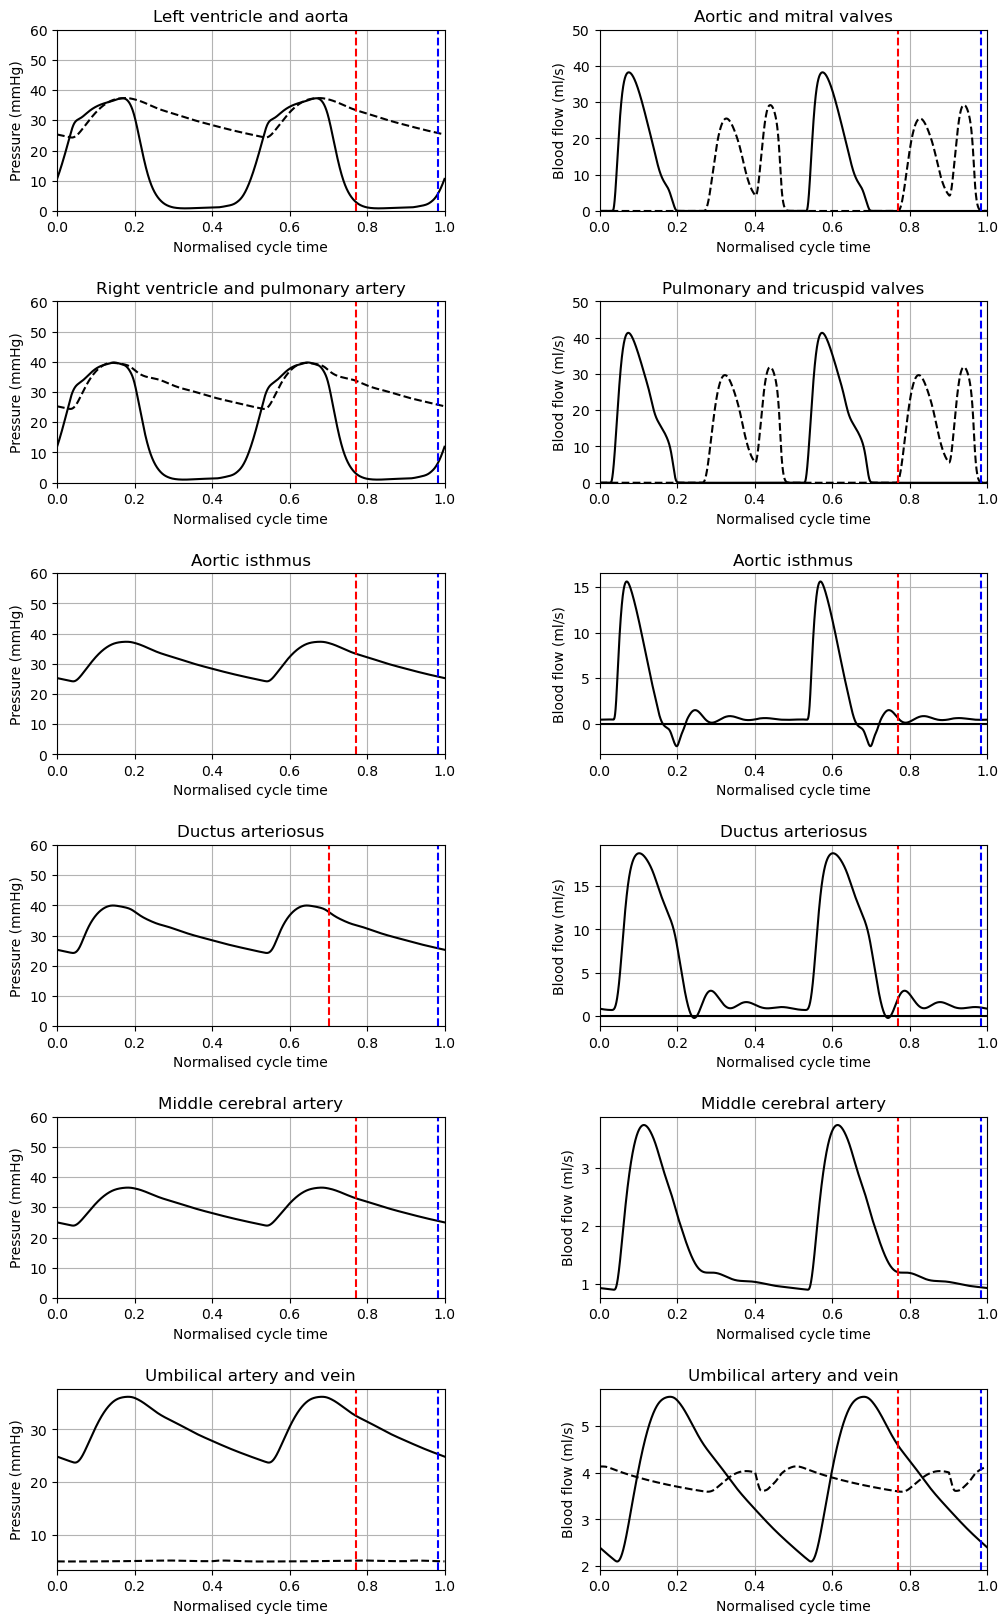

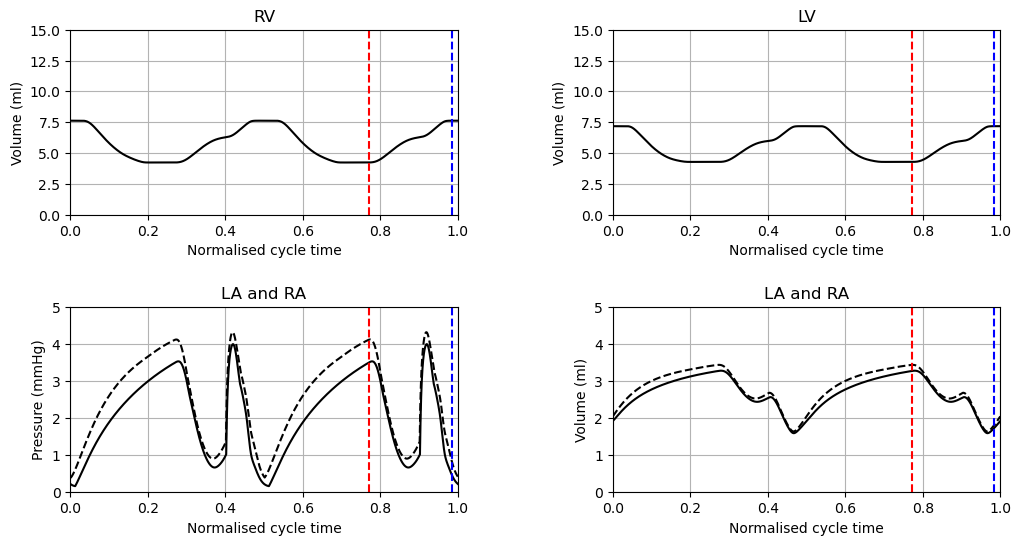

In [4]:
# Adjust parameters in hemodynamic model
v_change = [1] 
v_colors = ['k','b','g','m','r']

Tc = 0.43

_, f = plt.subplots(ncols = 2, nrows = 6, figsize = (12, 20))
f = f.flatten()
_, f2 = plt.subplots(ncols = 2, nrows = 2, figsize = (12, 6))
f2 = f2.flatten()

for index in range(len(v_change)): 
    color = v_colors[index]
    
    m = solver.model.ModelSolver('FETAL_MODEL_36_coronaries2.c')
    
    with fhealthy.HiddenPrints():
        tFinal = 100*Tc
        
        m.setConstantOrState0('Parameters', 'Rdv_fo', 1.825)
        m.setConstantOrState0('Parameters', 'Rdv_ra', 7.3)
        m.setConstantOrState0('Parameters', 'Kdv_fo', 0.3625)
        m.setConstantOrState0('Parameters', 'Kdv_ra', 1.45)
        
        m.solve(tFinal = tFinal) 

    default_plot(f,m,index+1,2,Tc,tFinal,color,True)
    dv_plot(f2,m,index+1,2,Tc,tFinal,color,True)


    idx = m.t > tFinal - Tc    
    CSV = np.trapz(m.getVariable('LV', 'Qo')[idx], m.t[idx]) + np.trapz(m.getVariable('RV', 'Qo')[idx], m.t[idx])
    print(f"")
    print(f"CSV = {CSV}")
    print(f"Coronaries = {np.round(np.trapz(m.getVariable('Bif_LVin_AA1out_Coronary2out', 'Qo2')[idx], m.t[idx])/CSV*100,2)} vs 3")
    print(f"AA = {np.round(np.trapz(m.getVariable('Bif_LVin_AA1out_Coronary2out', 'Qo1')[idx], m.t[idx])/CSV*100,2)} vs 44")
    print(f"MPA = {np.round(np.trapz(m.getVariable('RV', 'Qo')[idx], m.t[idx])/CSV*100,2)} vs 53")
    print(f"DA = {np.round(np.trapz(m.getVariable('Bif_PAin_LUNG1out_DA2out', 'Qo2')[idx], m.t[idx])/CSV*100,2)} vs 36")
    print(f"LUNG = {np.round(np.trapz(m.getVariable('Bif_PAin_LUNG1out_DA2out', 'Qo1')[idx], m.t[idx])/CSV*100,2)} vs 17")
    print(f"dAo = {np.round(np.trapz(m.getVariable('AO1_RC', 'Qo')[idx], m.t[idx])/CSV*100,2)} vs 53")
    print(f"SVC = {np.round(np.trapz(m.getVariable('SVC_RCL', 'Qo')[idx], m.t[idx])/CSV*100,2)} vs 27")
    print(f"UV = {np.round(np.trapz(m.getVariable('UV_RCL', 'Qo')[idx], m.t[idx])/CSV*100,2)} vs 26")
    print(f"FO = {np.round(np.trapz(m.getVariable('Bif_DV1in_IVC2in_FOout', 'Qo')[idx], m.t[idx])/CSV*100,2)} vs 30") # Kiserud Rasmussen
    print(f"DV/UV = {np.round(np.trapz(m.getVariable('Bif_UVin_DV1out_HE2out', 'Qo1')[idx], m.t[idx])/np.trapz(m.getVariable('UV_RCL', 'Qo')[idx], m.t[idx])*100,2)} vs 20-30")
    print(f"RA volume = {np.round(np.min(m.getVariable('RA','Vcav')[idx]),2)} - {np.round(np.max(m.getVariable('RA','Vcav')[idx]),2)} ml")
    print(f"Ejection fraction = {np.round(1-np.min(m.getVariable('RA','Vcav')[idx])/np.max(m.getVariable('RA','Vcav')[idx]),2)}")

    q_ua = m.getVariable('UA_RC', 'Qo')[idx]
    print(f"PI UA = {(np.max(q_ua)-np.min(q_ua))/np.mean(q_ua)}")

    

In [5]:
# Save mean blood flow in a cycle
input_variables_o2 = {
    "Q_PLAC": np.round(np.trapz(m.getVariable("UA_RC", "Qo")[idx]/0.43, m.t[idx]),3),
    "Q_BR": np.round(np.trapz((m.getVariable("ICaroAR_RCL", "Qo")[idx]+m.getVariable("ICaroAL_RCL", "Qo")[idx])/0.43, m.t[idx]),3),
    "Q_UB": np.round(np.trapz((m.getVariable("SubAR_RCL", "Qo")[idx]+m.getVariable("SubAL_RCL", "Qo")[idx])/0.43, m.t[idx]),3),
    "Q_DA": np.round(np.trapz(m.getVariable("Bif_PAin_LUNG1out_DA2out", "Qo2")[idx]/0.43, m.t[idx]),3),
    "Q_LUNG": np.round(np.trapz(m.getVariable("Bif_PAin_LUNG1out_DA2out", "Qo1")[idx]/0.43, m.t[idx]),3),
    "Q_AO": np.round(np.trapz(m.getVariable("AI_RCL", "Qo")[idx]/0.43, m.t[idx]),3),
    "Q_KID": np.round(np.trapz(m.getVariable("Bif_AOin_AO1out_INTE2out_HE3out_KID4out", "Qo4")[idx]/0.43, m.t[idx]),3),
    "Q_HeArt": np.round(np.trapz(m.getVariable("Bif_AOin_AO1out_INTE2out_HE3out_KID4out", "Qo3")[idx]/0.43, m.t[idx]),3),
    "Q_IntraHe": np.round(np.trapz(m.getVariable("Bif_UVin_DV1out_HE2out", "Qo2")[idx], m.t[idx])/0.43,3),
    "Q_INTE": np.round(np.trapz(m.getVariable("Bif_AOin_AO1out_INTE2out_HE3out_KID4out", "Qo2")[idx]/0.43, m.t[idx]),3),
    "Q_LEG": np.round(np.trapz(m.getVariable("Bif_AOin_LEG1out_UA2out", "Qo1")[idx]/0.43, m.t[idx]),3),
    "Q_DVfo": np.round(np.trapz(m.getVariable("Bif_DVin_FO1out_RA2out", "Qo1")[idx]/0.43, m.t[idx]),3),
    "Q_DVra": np.round(np.trapz(m.getVariable("Bif_DVin_FO1out_RA2out", "Qo2")[idx]/0.43, m.t[idx]),3),
    "Q_IVCfo": np.round(np.trapz(m.getVariable("Bif_IVCin_FO1out_RA2out", "Qo1")[idx]/0.43, m.t[idx]),3),
    "Q_IVCra": np.round(np.trapz(m.getVariable("Bif_IVCin_FO1out_RA2out", "Qo2")[idx]/0.43, m.t[idx]),3),
    "Q_CORONARIES": np.round(np.trapz(m.getVariable("Coronary_R", "Qo")[idx], m.t[idx])/0.43,3),}

print(f"var Q_PLAC: UnitQ {{init: {input_variables_o2['Q_PLAC']}00000000, pub: out}};")
print(f"var Q_BR: UnitQ {{init: {input_variables_o2['Q_BR']}00000000, pub: out}};")
print(f"var Q_UB: UnitQ {{init: {input_variables_o2['Q_UB']}00000000, pub: out}};")
print(f"var Q_DA: UnitQ {{init: {input_variables_o2['Q_DA']}00000000, pub: out}};")
print(f"var Q_LUNG: UnitQ {{init: {input_variables_o2['Q_LUNG']}00000000, pub: out}};")
print(f"var Q_AO: UnitQ {{init: {input_variables_o2['Q_AO']}00000000, pub: out}};")
print(f"var Q_KID: UnitQ {{init: {input_variables_o2['Q_KID']}00000000, pub: out}};")
print(f"var Q_HeArt: UnitQ {{init: {input_variables_o2['Q_HeArt']}00000000, pub: out}};")
print(f"var Q_IntraHe: UnitQ {{init: {input_variables_o2['Q_IntraHe']}00000000, pub: out}};")
print(f"var Q_INTE: UnitQ {{init: {input_variables_o2['Q_INTE']}00000000, pub: out}};")
print(f"var Q_LEG: UnitQ {{init: {input_variables_o2['Q_LEG']}00000000, pub: out}};")
print(f"var Q_DVfo: UnitQ {{init: {input_variables_o2['Q_DVfo']}00000000, pub: out}};")
print(f"var Q_DVra: UnitQ {{init: {input_variables_o2['Q_DVra']}00000000, pub: out}};")
print(f"var Q_IVCfo: UnitQ {{init: {input_variables_o2['Q_IVCfo']}00000000, pub: out}};")
print(f"var Q_IVCra: UnitQ {{init: {input_variables_o2['Q_IVCra']}00000000, pub: out}};")
print(f"var Q_CORONARIES: UnitQ {{init: {input_variables_o2['Q_CORONARIES']}00000000, pub: out}};")


var Q_PLAC: UnitQ {init: 3.85100000000, pub: out};
var Q_BR: UnitQ {init: 3.06300000000, pub: out};
var Q_UB: UnitQ {init: 0.80700000000, pub: out};
var Q_DA: UnitQ {init: 5.38300000000, pub: out};
var Q_LUNG: UnitQ {init: 2.48200000000, pub: out};
var Q_AO: UnitQ {init: 2.39500000000, pub: out};
var Q_KID: UnitQ {init: 0.74400000000, pub: out};
var Q_HeArt: UnitQ {init: 0.28300000000, pub: out};
var Q_IntraHe: UnitQ {init: 2.64600000000, pub: out};
var Q_INTE: UnitQ {init: 0.5600000000, pub: out};
var Q_LEG: UnitQ {init: 2.3400000000, pub: out};
var Q_DVfo: UnitQ {init: 0.88800000000, pub: out};
var Q_DVra: UnitQ {init: 0.31700000000, pub: out};
var Q_IVCfo: UnitQ {init: 3.34700000000, pub: out};
var Q_IVCra: UnitQ {init: 3.22600000000, pub: out};
var Q_CORONARIES: UnitQ {init: 0.45300000000, pub: out};


cO2i_f = 0.12706705002058793
pO2i_f = 21.370308727781467


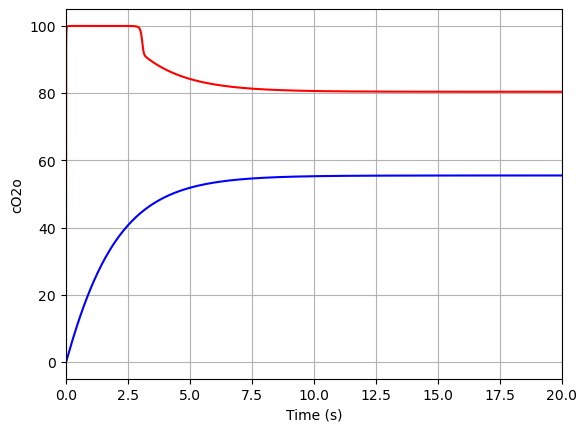

In [6]:
# Initialize oxygen transport model
v_change = [1,1,1] 
v_change2 = [2.53659,2,1.5] 
v_colors = ['b','g','m','r']
 
path = 'CIRCULATION_CORONARIES.so'
m = solver.model.ModelSolver('Healthy_O2_model.c', wrapper = solver.model.cwrapping.ClibWrapper(cLibPath = path))
total_consumption = 0.22
with fhealthy.HiddenPrints():
    tFinal = 20
    [m.setConstantOrState0('Parameters', key, value) for key, value in input_variables_o2.items()]
    m.setConstantOrState0('Parameters', 'QM_CORONARIES', 0.08*total_consumption) # 8%
    m.setConstantOrState0('Parameters', 'QM_BR', 0.57*total_consumption)         # 57%
    m.setConstantOrState0('Parameters', 'QM_UB', 0.024*total_consumption)        # 2.4% 
    m.setConstantOrState0('Parameters', 'QM_KID', 0.08*total_consumption)        # 8%
    m.setConstantOrState0('Parameters', 'QM_LEG', 0.07*total_consumption)        # 7%
    m.setConstantOrState0('Parameters', 'QM_LUNG', 0.08*total_consumption)       # 8%
    m.setConstantOrState0('Parameters', 'QM_INTE', 0.016*total_consumption)      # 1.6%
    m.setConstantOrState0('Parameters', 'QM_HE', 0.08*total_consumption)         # 8%
    m.solve(tFinal = tFinal) 
    
plt.plot(m.t,m.getVariable('Bif_AO1in_DA2in_dAOout', 'SO2'),color='b',linestyle='-',linewidth = 1.5)
plt.plot(m.t,m.getVariable('PLAC', 'SO2'),color='r',linestyle='-',linewidth = 1.5)
plt.xlabel('Time (s)')
plt.ylabel('cO2o')
plt.grid(color = [0.7,0.7,0.7,1])
plt.xlim([0,20])

constants_names = ['QM_CORONARIES','QM_BR','QM_UB','QM_KID','QM_LEG','QM_LUNG','QM_INTE','QM_HE','D_PLAC']
default_constants = {element: m.getConstant('Parameters', element) for element in constants_names}

print(f"cO2i_f = {m.getVariable('Bif_AO1in_DA2in_dAOout', 'cO2o')[-1]}") 
print(f"pO2i_f = {m.getVariable('Bif_AO1in_DA2in_dAOout', 'pO2')[-1]}") 

In [7]:
print(f"Oxygen saturation ascending aorta: {np.round(m.getVariable('LV', 'SO2')[-1],3)} vs 58")
print(f"Oxygen saturation main pulmonary artery: {np.round(m.getVariable('RV', 'SO2')[-1],3)} vs 52")
print(f"Oxygen saturation descending aorta: {np.round(m.getVariable('Bif_AO1in_DA2in_dAOout', 'SO2')[-1],3)} vs 53")
print(f"Oxygen saturation umbilical vein: {np.round(m.getVariable('PLAC', 'SO2')[-1],3)} vs 80")
print(f"Oxygen saturation superior vena cava: {np.round(m.getVariable('Bif_BR1in_UB2in_SVCout', 'SO2')[-1],3)} vs 44")


Oxygen saturation ascending aorta: 60.099 vs 58
Oxygen saturation main pulmonary artery: 53.438 vs 52
Oxygen saturation descending aorta: 55.489 vs 53
Oxygen saturation umbilical vein: 80.402 vs 80
Oxygen saturation superior vena cava: 45.343 vs 44


In [8]:
print(f"Before brain: {np.round(m.getVariable('Bif_UPin_BR1out_UB2out', 'SO2_1')[-1],3)}")
print(f"After brain: {np.round(m.getVariable('BR', 'SO2')[-1],3)}")


Before brain: 60.099
After brain: 42.207


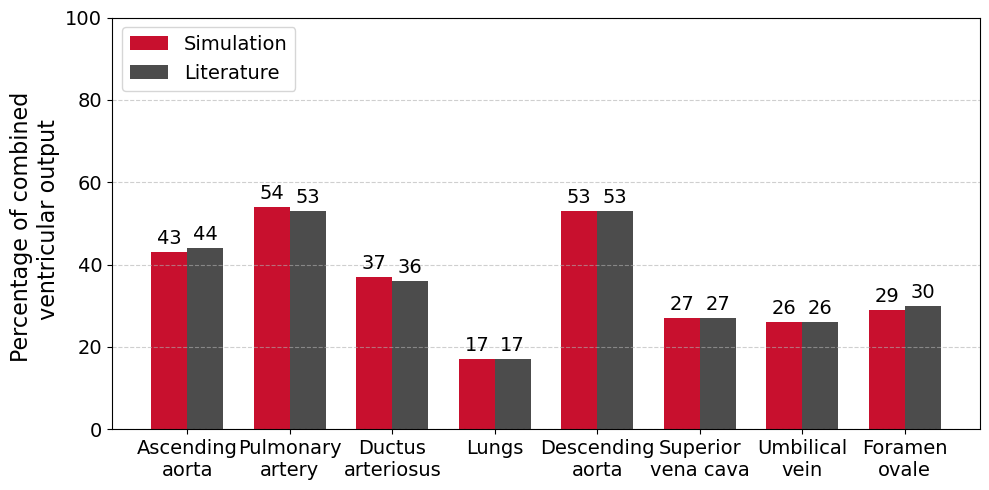

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Data
locations = ["Ascending\naorta","Pulmonary\nartery","Ductus\narteriosus","Lungs","Descending\naorta","Superior\nvena cava","Umbilical\nvein","Foramen\novale"]

simulation = np.array([43, 54, 37, 17, 53, 27, 26, 29])
literature = np.array([44, 53, 36, 17, 53, 27, 26, 30])

# Positions
x = np.arange(len(locations))
width = 0.35

# Figure
fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, simulation, width, label='Simulation', color='#C8102E')
bars2 = ax.bar(x + width/2, literature, width, label='Literature', color='#4C4C4C')

ax.bar_label(bars1, padding=3, fontsize=14)
ax.bar_label(bars2, padding=3, fontsize=14)

# Format
plt.xticks(x, locations, ha='center',fontsize=14)
ax.set_yticks(np.arange(0, 101, 20))
plt.yticks(fontsize=14)
plt.ylabel('Percentage of combined \n ventricular output',fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim([0,100])

plt.tight_layout()
fig.savefig(f"./Plots/CVO.pdf", format='pdf', bbox_inches='tight')
plt.show()

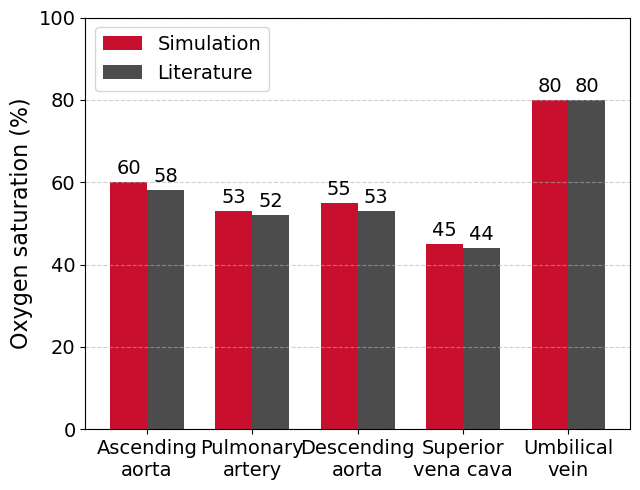

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Data
locations = [
    "Ascending\naorta",
    "Pulmonary\nartery",
    "Descending\naorta",
    "Superior\nvena cava",
    "Umbilical\nvein"
]

simulation = np.array([60, 53, 55, 45, 80])
literature = np.array([58, 52, 53, 44, 80])

# Positions
x = np.arange(len(locations))
width = 0.35

# Figure
fig, ax = plt.subplots(figsize=(6.5, 5))

bars1 = ax.bar(x - width/2, simulation, width, label='Simulation', color='#C8102E')
bars2 = ax.bar(x + width/2, literature, width, label='Literature', color='#4C4C4C')

ax.bar_label(bars1, padding=3, fontsize=14)
ax.bar_label(bars2, padding=3, fontsize=14)

# Format
ax.set_xticks(x)
ax.set_xticklabels(locations, ha='center', fontsize=14)
ax.set_yticks(np.arange(0, 101, 20))
ax.tick_params(axis='y', labelsize=14)

ax.set_ylabel('Oxygen saturation (%)', fontsize=16)
ax.legend(fontsize=14, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.6)

ax.set_ylim([0, 100])

plt.tight_layout()
fig.savefig(f"./Plots/SO2.pdf", format='pdf', bbox_inches='tight')
plt.show()